In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from keras.utils import plot_model
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np 

In [5]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()

In [9]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

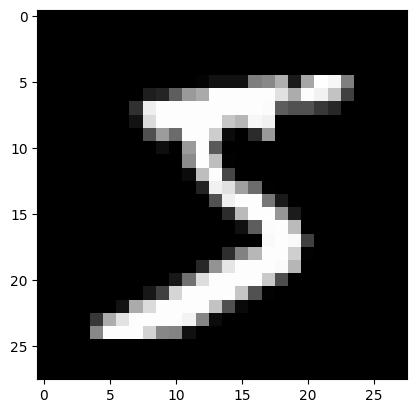

In [8]:
plt.imshow(x_train[0], cmap = 'gray')

In [10]:
y_train[0]

5

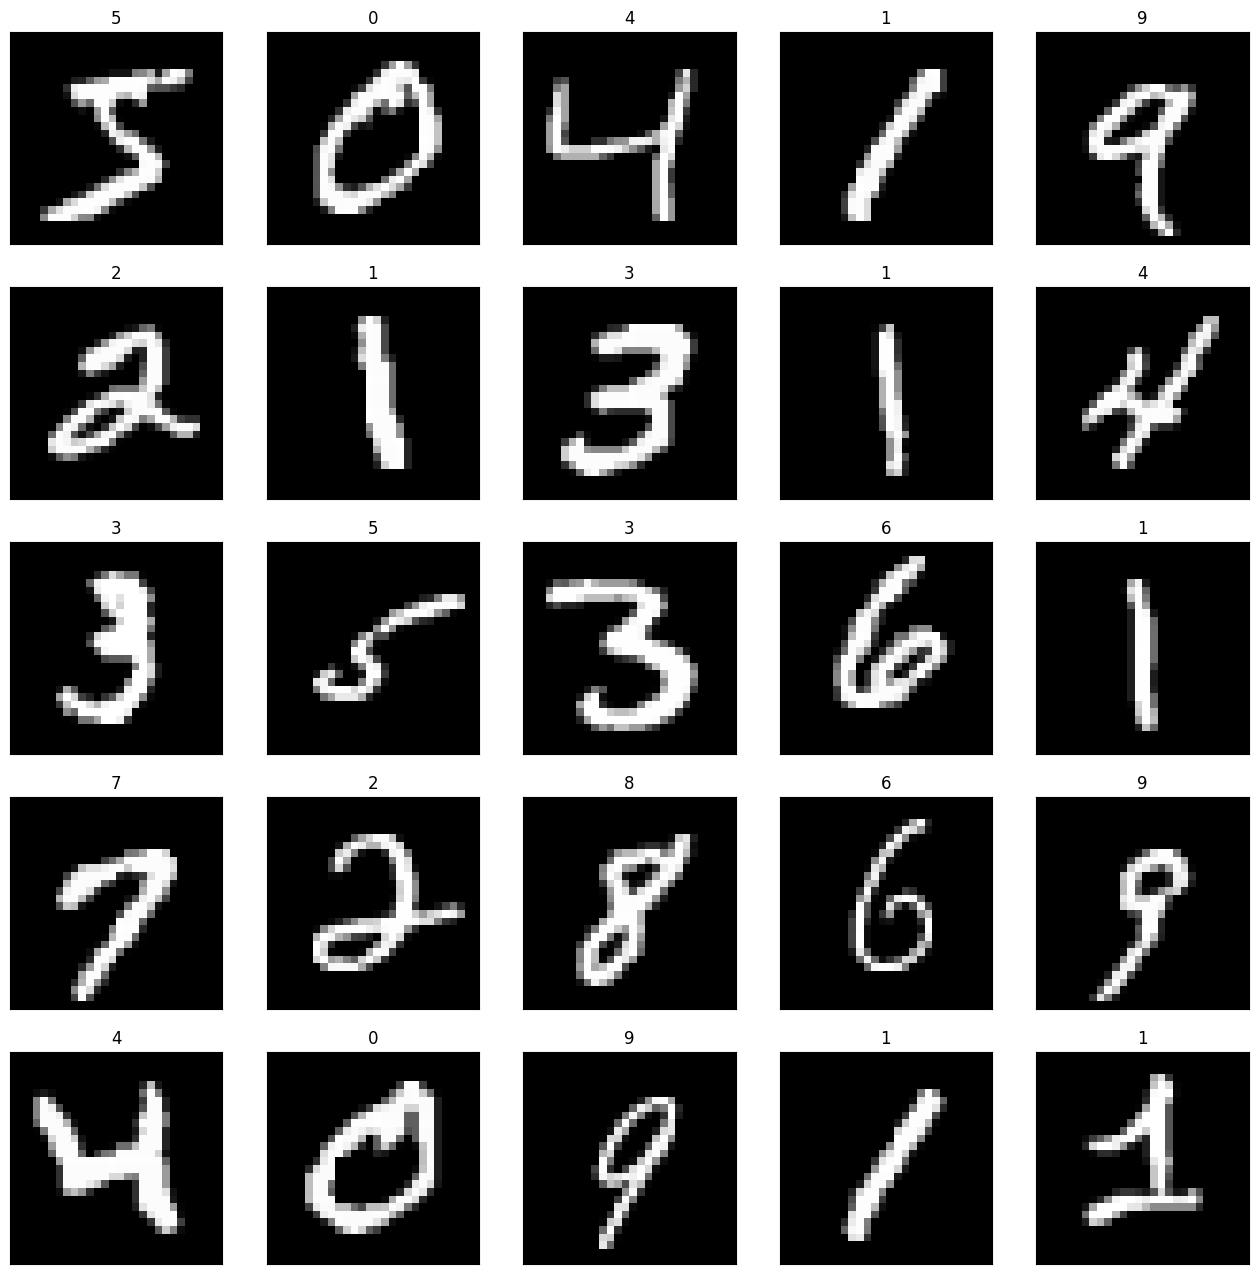

In [15]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap = 'gray')
    plt.title(y_train[i])
    plt.xticks([]); plt.yticks([])

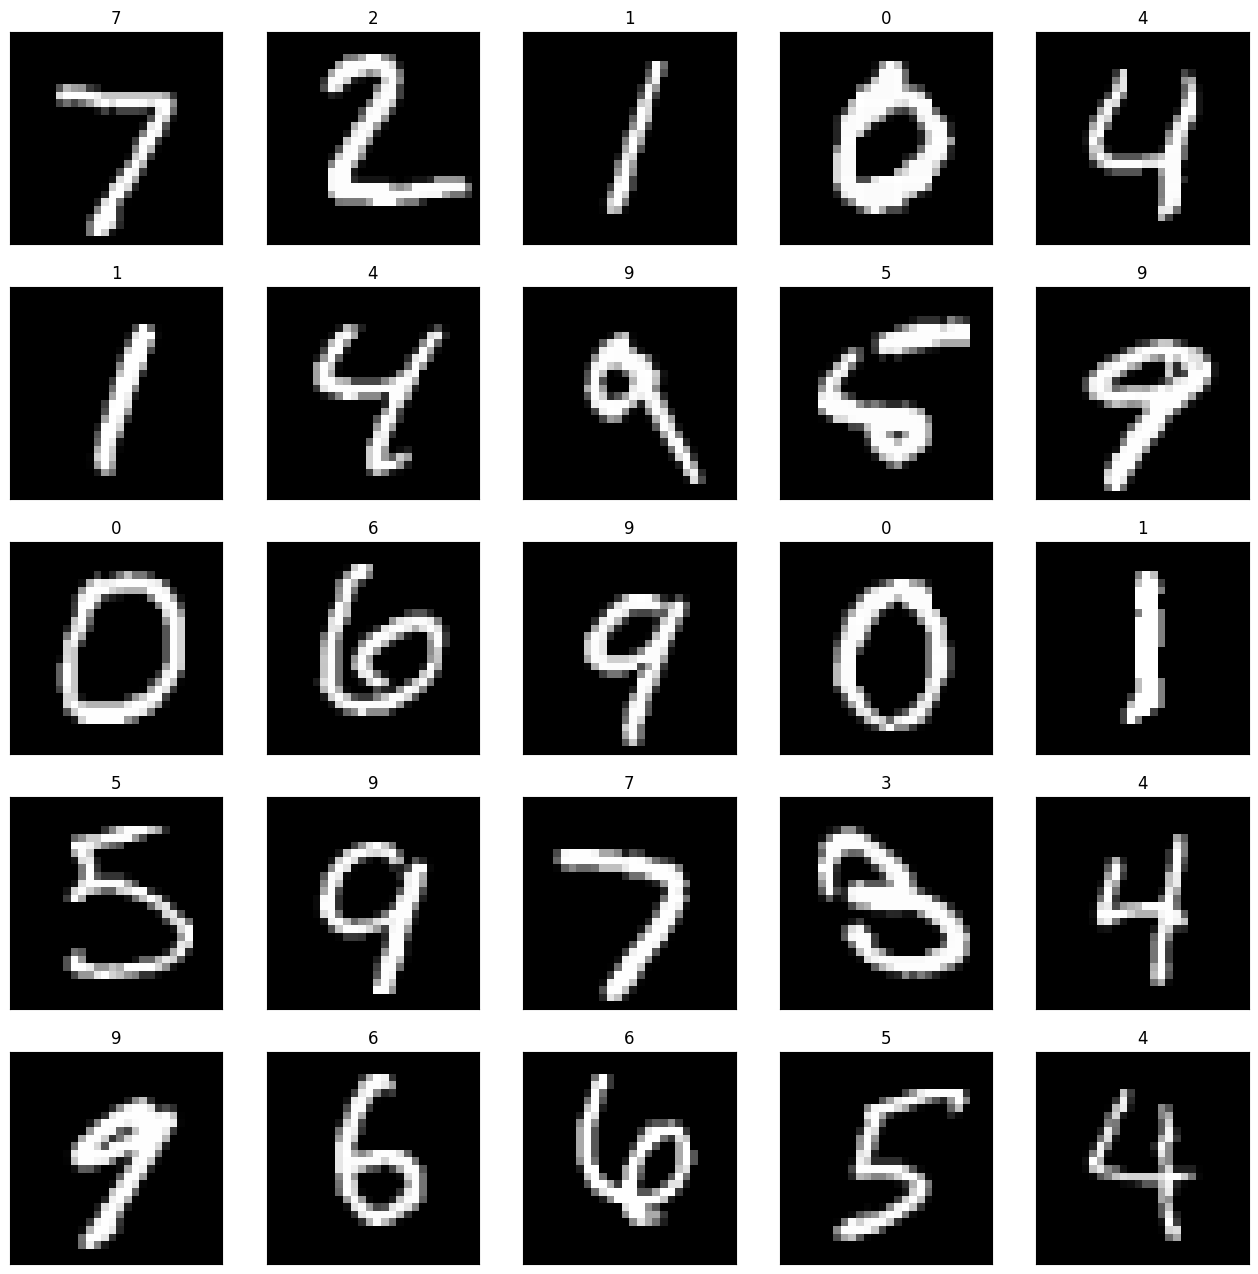

In [16]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap = 'gray')
    plt.title(y_test[i])
    plt.xticks([]); plt.yticks([])

In [17]:
import seaborn as sns

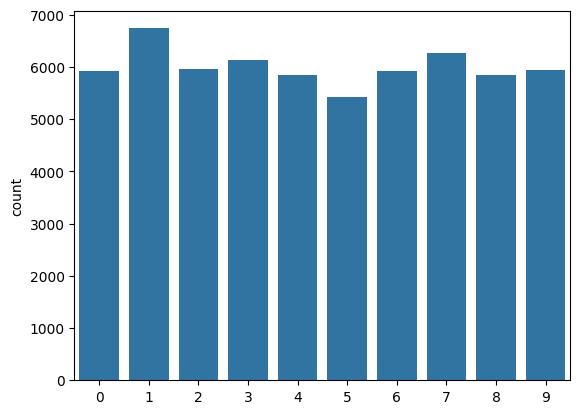

In [19]:
sns.countplot(x = y_train);

In [20]:
# Normalize
x_train = x_train / 255 
x_test = x_test / 255

In [21]:
x_train.shape

(60000, 28, 28)

In [22]:
x_test.shape

(10000, 28, 28)

In [23]:
x_train = x_train.reshape(-1, x_train[0].size)

In [25]:
x_train.shape

(60000, 784)

In [26]:
x_test = x_test.reshape(-1, x_test[0].size)

In [27]:
x_test.shape

(10000, 784)

In [28]:
y_train.shape

(60000,)

In [29]:
from keras.utils import to_categorical

In [30]:
y_train_new = to_categorical(y_train)
y_test_new = to_categorical(y_test)

In [31]:
y_train_new.shape

(60000, 10)

In [32]:
y_test_new.shape

(10000, 10)

#### Build the model

In [36]:
model = Sequential()

model.add(Input(shape=(784,)))

model.add(Dense(512, activation='relu'))

model.add(Dense(256, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss='categorical_crossentropy', optimizer='adam',
             metrics=['accuracy'])

In [39]:
model.fit(x_train, y_train_new, epochs=10, batch_size=10) 

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9102 - loss: 0.2925
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9721 - loss: 0.0925
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9824 - loss: 0.0587
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9851 - loss: 0.0496
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9872 - loss: 0.0422
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9877 - loss: 0.0391
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9899 - loss: 0.0344
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9915 - loss: 0.0288
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9928 - loss: 0.0262
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9939 - loss: 0.0247


In [40]:
model.evaluate(x_test, y_test_new, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9802 - loss: 0.1477


[0.1243923231959343, 0.9814000129699707]

#### Predict on unseen data

In [42]:
import cv2

In [47]:
new = cv2.imread('images/new-char1.jpg', 0)
new = cv2.resize(new, (28,28))
thresh, new = cv2.threshold(new, 127,255, cv2.THRESH_BINARY_INV)

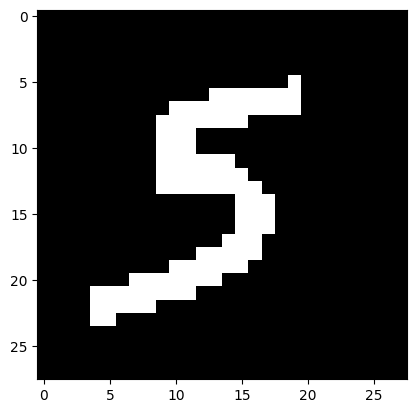

In [48]:
plt.imshow(new, cmap = 'gray')

In [50]:
new = new.reshape(1,784)
result = model.predict(new, verbose=False)
print(np.argmax(result))

5
